E0000 00:00:1773660729.393539   51833 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1773660729.394100   51833 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1773660729.394108   51833 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1773660729.394111   51833 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1773660729.394113   51833 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.
/home/user/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage modu

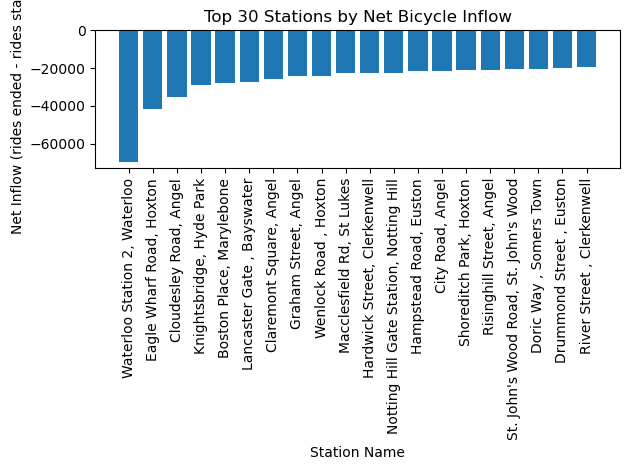

In [1]:
from google.cloud import bigquery
import pandas as pd
import matplotlib.pyplot as plt

# Initialize BigQuery client
client = bigquery.Client()

query = """
WITH starts AS (
  SELECT b.station_name as start_station_name, COUNT(*) AS start_count
  FROM `bigdata-488403.london_bicycles_star.fact_hire` a
  LEFT JOIN `bigdata-488403.london_bicycles_star.dim_station` b
  on a.start_station_id = b.station_id
  GROUP BY start_station_name
),
ends AS (
  SELECT d.station_name as end_station_name, COUNT(*) AS end_count
  FROM `bigdata-488403.london_bicycles_star.fact_hire` c
  LEFT JOIN `bigdata-488403.london_bicycles_star.dim_station` d
  on c.end_station_id = d.station_id
  GROUP BY end_station_name
)
SELECT
  COALESCE(s.start_station_name, e.end_station_name) AS station_name,
  COALESCE(start_count, 0) AS rides_started,
  COALESCE(end_count, 0) AS rides_ended,
  COALESCE(end_count, 0) - COALESCE(start_count, 0) AS net_inflow
FROM starts s
FULL OUTER JOIN ends e
  ON s.start_station_name = e.end_station_name
where (COALESCE(end_count, 0) - COALESCE(start_count, 0)) < 0  
ORDER BY net_inflow ASC
"""

# Run query
query_job = client.query(query, location="EU")

# Convert to DataFrame
df = query_job.to_dataframe()

# Limit to top 20 stations for readability
df_top = df.head(20)

# Plot bar chart
plt.figure()
plt.bar(df_top["station_name"], df_top["net_inflow"])

plt.title("Top 30 Stations by Net Bicycle Inflow")
plt.xlabel("Station Name")
plt.ylabel("Net Inflow (rides ended - rides started)")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()